# Feedfoward Neural Networks: A Quick Primer for Deep Learning

Modern machine translation, search engines, mobile applications, and computer assistants are all equipped with deep learning technology. There are many classic machine learning algorithms and statistical algorithms which can be applied to data. By mimicking the human brain, deep learning models can work wonders when it comes to finding and creating patterns from data.

As deep learning reaches into a plethora of industries, it’s becoming essential for software engineers to develop a work knowledge of its principles. We’ll take an in-depth look at feedforward neural networks, an important part of the core neural network architecture.

## Content

* A quick intro to neural networks
* How feedfoward neural networks work
* Coding a feedforward neural network in TensorFlow

---

## 1. A Quick Intro to Neural Networks
A neural network is a machine learning model inspired by the structure and function of the human brain. It consists of interconnected nodes (neurons) organized into layers that process data, learn patterns, and make predictions.

The Real-World Example: House Price Prediction
Imagine you want to predict the price of a house based on three basic features: Square Footage, Number of Bedrooms, and Zip Code (Location).

* Input Layer: This is where your raw features enter the network. Each feature gets its own node.

* Hidden Layer: This layer combines the features to find hidden patterns. For instance, one neuron might combine "Square Footage" and "Bedrooms" to calculate a hidden feature like "Family Living Space Size." Another might combine "Zip Code" and "Square Footage" to determine "Location Premium."

* Output Layer: The final node that combines the hidden patterns to output a single continuous number: the Predicted Price.

---

## Feedforward Neural Network Structure

In a Feedforward Neural Network, data flows in only one direction (input → hidden → output).

---

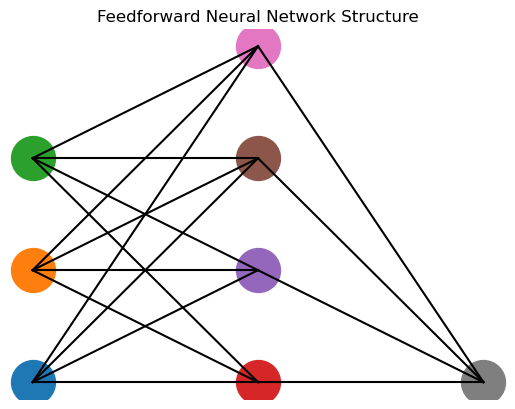

In [2]:
import matplotlib.pyplot as plt

layers = [3, 4, 1]  # Input, Hidden, Output

for i, layer_size in enumerate(layers):
    for j in range(layer_size):
        plt.scatter(i, j, s=1000)

# connections input → hidden
for i in range(3):
    for j in range(4):
        plt.plot([0, 1], [i, j], 'k-')

# connections hidden → output
for j in range(4):
    plt.plot([1, 2], [j, 0], 'k-')

plt.title("Feedforward Neural Network Structure")
plt.axis('off')
plt.show()

## 2. How Feedforward Neural Networks Work

A Feedforward Neural Network (FNN) is the simplest type of artificial neural network. In an FNN, information moves in only one direction—forward—from the input nodes, through the hidden nodes, and to the output nodes. There are no loops or cycles in the network.

**The Mathematical Example:** A Single Neuron's Decision

Let's look under the hood of a single hidden neuron determining if a house is a "Good Deal" ($1$) or "Overpriced" ($0$) based on two inputs: Price ($x_1$) and Condition Rating ($x_2$).

Information processes forward through three distinct steps:

* Weighted Sum ($z$): The network assigns weights ($w$) to show the importance of each input, and adds a bias ($b$) to shift the decision threshold.
  
  $$z = (x_1 \cdot w_1) + (x_2 \cdot w_2) + b$$
  
* Activation Function ($a$): The weighted sum is passed through an activation function (like Sigmoid or ReLU) to introduce non-linearity, allowing the network to learn complex, non-straight-line patterns.

  
  $$a = \text{Sigmoid}(z)$$

**Step-by-Step Numerical Walkthrough**

Suppose our network has already learned these weights and biases:

* Inputs: Price ($x_1 = 0.8$), Condition ($x_2 = 0.9$) (normalized between 0 and 1)
* Weights: $w_1 = -2.0$ (High price is bad), $w_2 = 3.0$ (High condition is good)
* Bias: $b = -0.5$

Let's calculate the forward pass:

**Step 1:**   

$z$ = (0.8 . -2.0) + (0.9 . 3.0) + (-0.5)z = -1.6 + 2.7 - 0.5 = 0.6

**Step 2:**  

$a$ = (Sigmoid)(0.6) = 1/{1 + e^{-0.6}} = 0.646

---

**Output:** 

The network outputs 0.646, meaning there is a 64.6% chance this house is a good deal.

---

## 2. Neuron Computation (Weighted Sum + Activation)

A neuron multiplies inputs by weights, adds a bias, and applies an activation function.

---

Weighted Sum: 3.25
Neuron Output: 0.9626731126558706


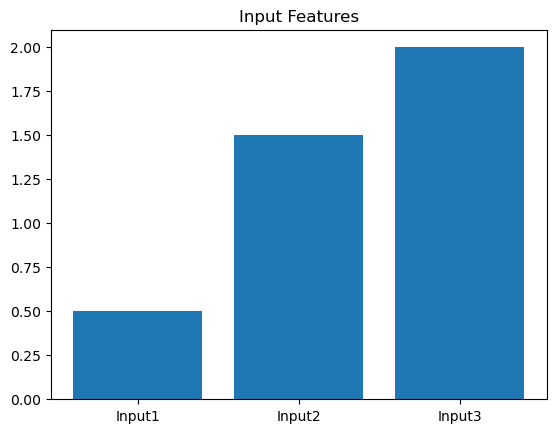

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs and weights
x = np.array([0.5, 1.5, 2.0])
w = np.array([0.4, 0.3, 0.8])
b = 1

# Weighted sum
z = np.dot(x, w) + b

# Sigmoid activation
output = 1 / (1 + np.exp(-z))

print("Weighted Sum:", z)
print("Neuron Output:", output)

# Visualization
plt.bar(["Input1","Input2","Input3"], x)
plt.title("Input Features")
plt.show()

---
## 3. Coding a Feedforward Neural Network in TensorFlow

Let's implement a complete Feedforward Neural Network using TensorFlow/Keras to solve a classic classification problem: classifying handwritten digits (0-9) using the MNIST dataset.

---

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load and preprocess the data
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0.0 and 1.0
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Build the Feedforward Neural Network architecture
model = models.Sequential([
    # Flatten the 28x28 pixel images into a 1D vector of 784 pixels (Input Layer)
    layers.Flatten(input_shape=(28, 28)),
    
    # First Hidden Layer with 128 neurons and ReLU activation
    layers.Dense(128, activation='relu'),
    
    # Second Hidden Layer with 64 neurons and ReLU activation
    layers.Dense(64, activation='relu'),
    
    # Output Layer with 10 nodes (one for each digit 0-9) and Softmax activation
    layers.Dense(10, activation='softmax')
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the network structure
model.summary()

# 4. Train the model
print("\n--- Starting Training ---")
model.fit(X_train, y_train, epochs=3, batch_size=64)

# 5. Evaluate the model on unseen test data
print("\n--- Model Evaluation ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


C:\Users\B\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9197 - loss: 0.2781
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9660 - loss: 0.1129
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9761 - loss: 0.0784

--- Model Evaluation ---
313/313 - 1s - 5ms/step - accuracy: 0.9730 - loss: 0.0858
